# **Customer Segmentation using K-Means Clustering**

## **Import Libraries**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## **Loading Dataset**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers (1).csv to Mall_Customers (1).csv


## **Dataset Overview**

In [4]:
df = pd.read_csv("Mall_Customers (1).csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

(200, 5)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## **Missing Value Analysis**

In [16]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## **Exploratory Data Analysis**

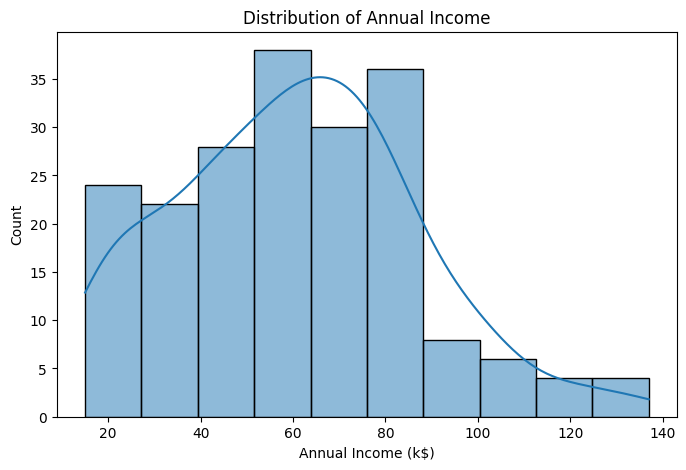

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], kde=True)

plt.title("Distribution of Annual Income")

plt.show()

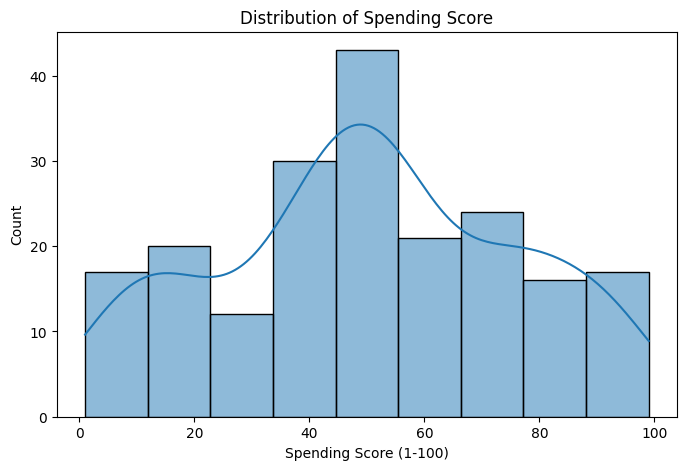

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], kde=True)

plt.title("Distribution of Spending Score")

plt.show()

## **Outlier Detection**

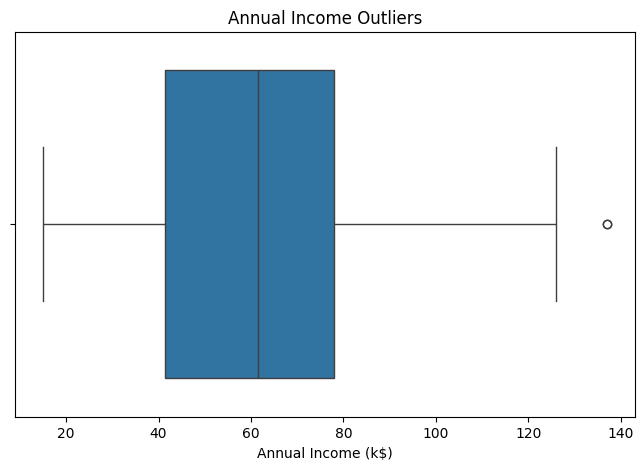

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Annual Income (k$)'])

plt.title("Annual Income Outliers")

plt.show()

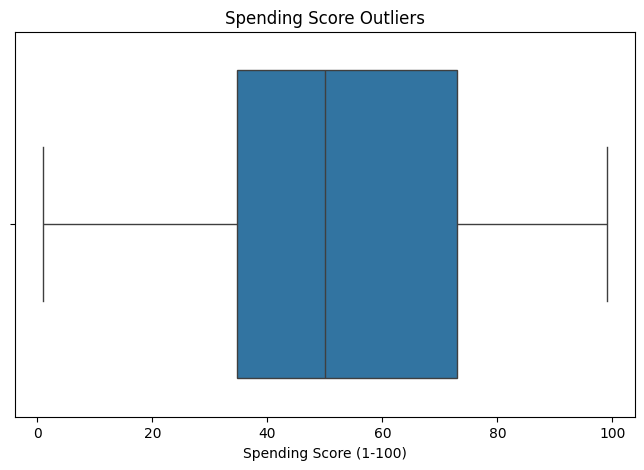

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Spending Score (1-100)'])

plt.title("Spending Score Outliers")

plt.show()

## **Correlation Analysis**

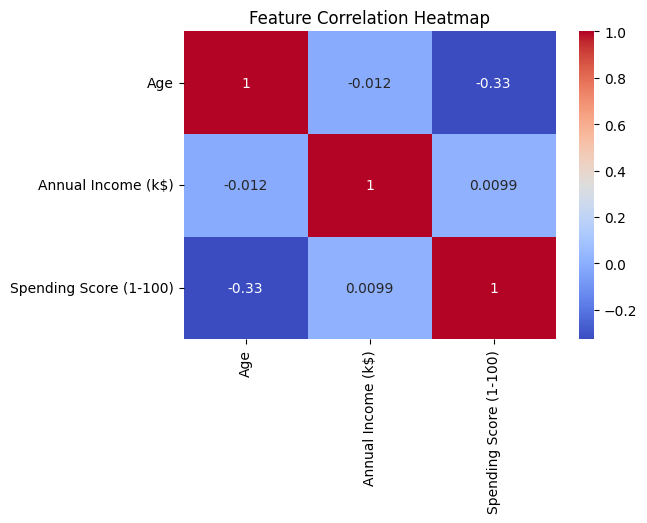

In [27]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

## **Feature Selection**

In [17]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

## **Feature Scaling**

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## **Finding Optimal Clusters using Elbow Method**

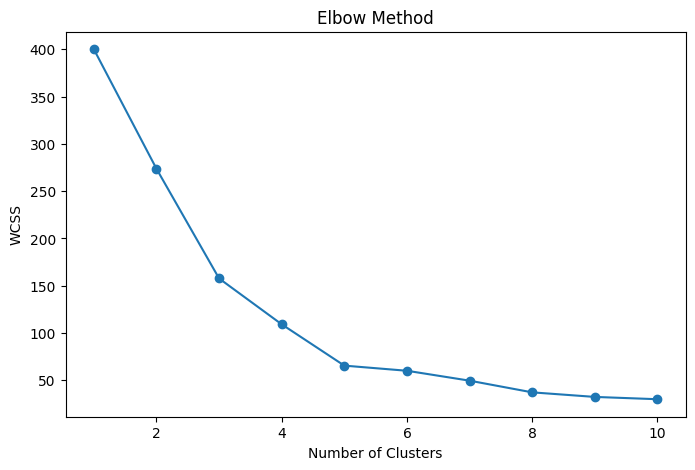

In [19]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

## **Building K-Means Clustering Model**

In [25]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)
y_kmeans = kmeans.fit_predict(X_scaled)

## **Model Evaluation**

In [26]:
score = silhouette_score(X_scaled, y_kmeans)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


A silhouette score closer to 1 indicates well-separated customer clusters.

## **Visualizing Customer Segments**

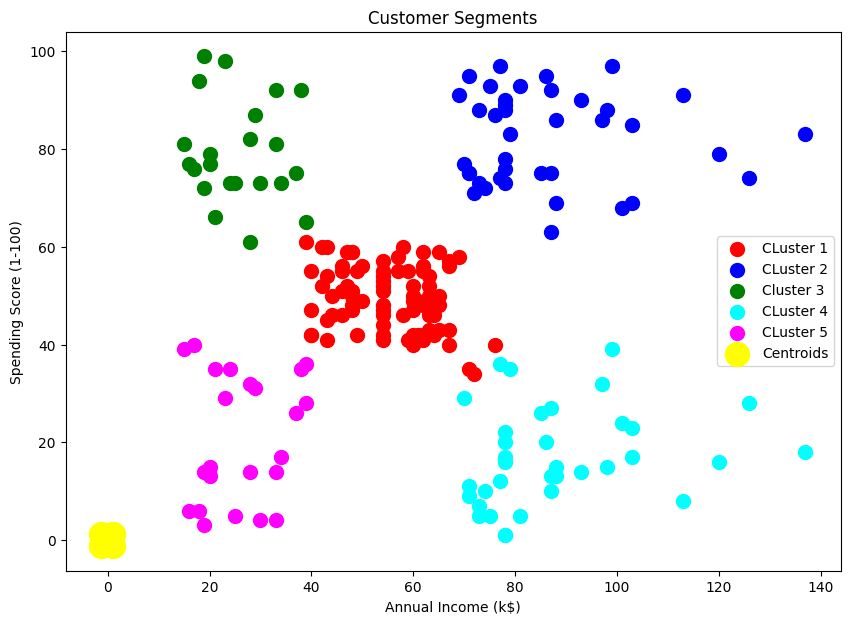

In [29]:
plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[y_kmeans == 0, 0],
    X.iloc[y_kmeans == 0, 1],
    s=100,
    c="red",
    label = "CLuster 1"
)

plt.scatter(
    X.iloc[y_kmeans == 1, 0],
    X.iloc[y_kmeans == 1, 1],
    s=100,
    c="blue",
    label = "CLuster 2"
)

plt.scatter(
    X.iloc[y_kmeans == 2, 0],
    X.iloc[y_kmeans == 2, 1],
    s=100,
    c='green',
    label = "Cluster 3"
)

plt.scatter(
    X.iloc[y_kmeans == 3, 0],
    X.iloc[y_kmeans == 3, 1],
    s=100,
    c="cyan",
    label = "CLuster 4"
)

plt.scatter(
    X.iloc[y_kmeans == 4, 0],
    X.iloc[y_kmeans == 4, 1],
    s=100,
    c="magenta",
    label = "CLuster 5"
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='yellow',
    label = "Centroids"
)
plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## **Adding Cluster Labels**

In [30]:
df['Cluster'] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


##**Conclusion**

The K-Means clustering algorithm successfully segmented customers into 5 distinct groups based on annual income and spending behavior.

###**Business Insights**

- High income and high spending customers are premium customers.
- High income but low spending customers can be targeted with personalized marketing.
- Low income but high spending customers respond well to discounts and offers.
- Medium income customers form the majority customer base.and decision-making strategies.